In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
import re

def parse_metrics_from_file(filepath):
    """
    Reads a text file and extracts RRMSE, RCRPS, and CovDiff values.

    This function opens a file, reads it line by line, and uses regular
    expressions to find lines containing specific metrics. It then parses
    the floating-point number that appears before the '±' symbol and
    appends it to the corresponding list.

    Args:
        filepath (str): The full path to the input text file.

    Returns:
        tuple: A tuple containing three lists in the following order:
               - rrmse_list (list of floats)
               - rcrps_list (list of floats)
               - covdiff_list (list of floats)
    """
    # Initialize empty lists to store the extracted values.
    rrmse_list = []
    rcrps_list = []
    covdiff_list = []

    # Define regular expressions to find the lines and extract the numbers.
    # This looks for the metric name, followed by a space, then captures
    # a floating-point number before the ' ±' part.
    rrmse_pattern = re.compile(r"RRMSE: (\d+\.\d+) ± .*")
    rcrps_pattern = re.compile(r"RCRPS: (\d+\.\d+) ± .*")
    covdiff_pattern = re.compile(r"CovDiff: (\d+\.\d+) ± .*")

    # Open and read the file line by line.
    try:
        with open(filepath, 'r') as f:
            for line in f:
                # Check for RRMSE match
                rrmse_match = rrmse_pattern.match(line)
                if rrmse_match:
                    # If matched, convert the captured group to float and append.
                    rrmse_list.append(float(rrmse_match.group(1)))
                    continue # Move to the next line

                # Check for RCRPS match
                rcrps_match = rcrps_pattern.match(line)
                if rcrps_match:
                    # If matched, convert the captured group to float and append.
                    rcrps_list.append(float(rcrps_match.group(1)))
                    continue # Move to the next line

                # Check for CovDiff match
                covdiff_match = covdiff_pattern.match(line)
                if covdiff_match:
                    # If matched, convert the captured group to float and append.
                    covdiff_list.append(float(covdiff_match.group(1)))

    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
        return [], [], []
    except Exception as e:
        print(f"An error occurred: {e}")
        return [], [], []

    # Return the three lists containing the extracted values.
    return rrmse_list, rcrps_list, covdiff_list

/tmp/ipykernel_26476/961549672.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(file_name)


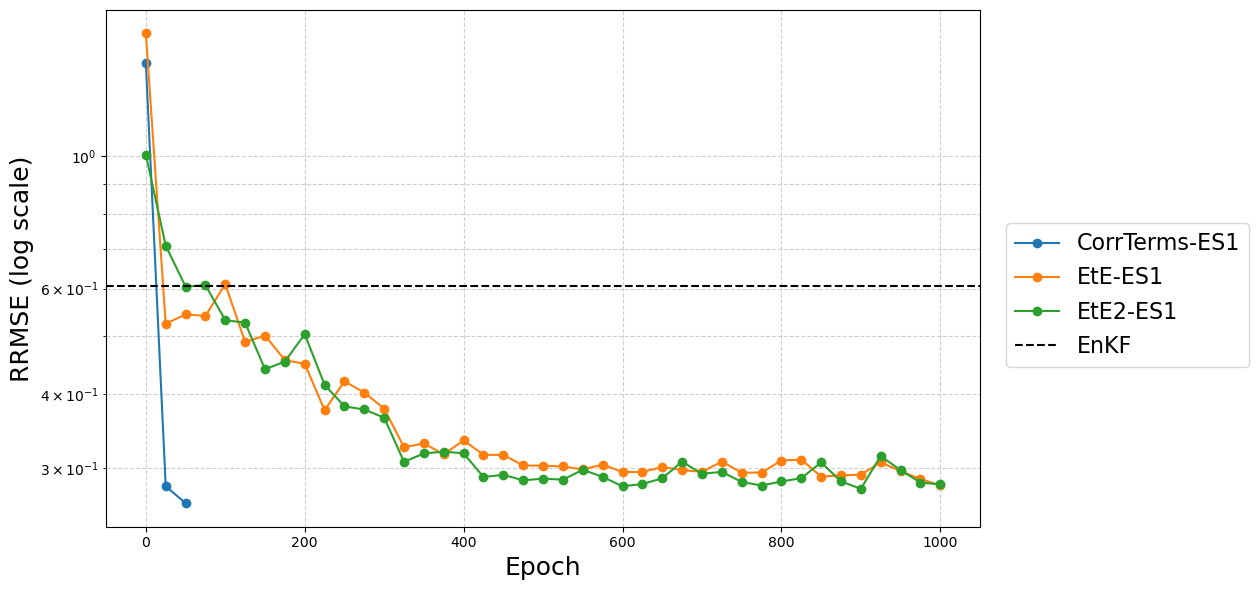

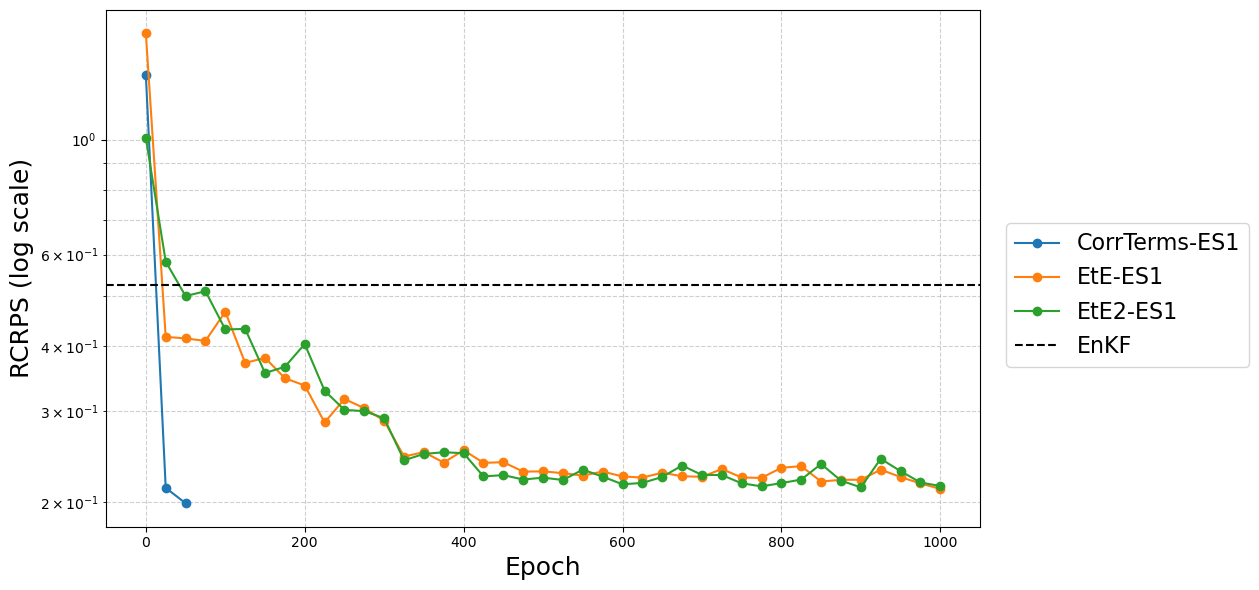

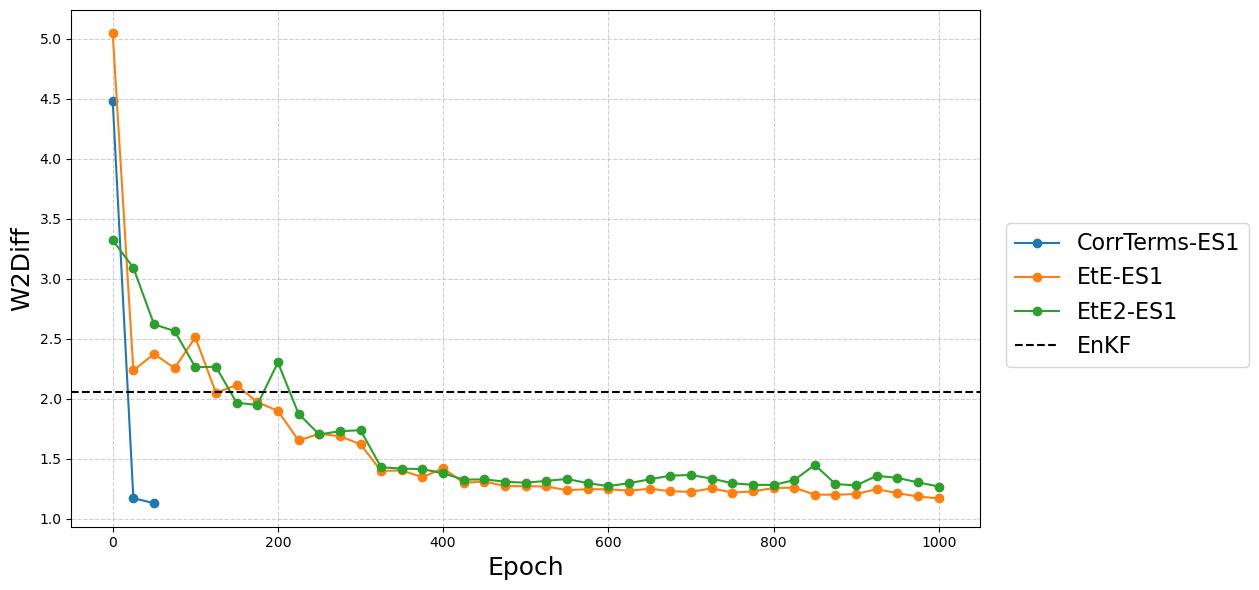

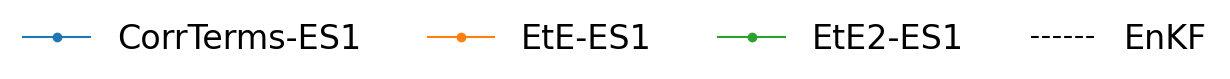

In [4]:
EnKF_RRMSE = 0.605
EnKF_RCRPS = 0.524
EnKF_W2 = 2.055

folder_names = ['2025-06-28_21-46linear_1_10_60_8192_es_joint_CorrTerms',
                '2025-06-28_21-46linear_1_10_60_8192_es_joint_EtE2',
                '2025-06-28_21-46linear_1_10_60_8192_es_joint_EtE',
               ]

method_names = ['CorrTerms-ES1',
                'EtE-ES1', 
                'EtE2-ES1', 
               ]

test_epochs = torch.arange(0, 1001, 25)

fig_rrmse, ax_rrmse = plt.subplots(figsize=(10, 6))
fig_rcrps, ax_rcrps = plt.subplots(figsize=(10, 6))
fig_w2diff, ax_w2diff = plt.subplots(figsize=(10, 6))

for i, folder_name in enumerate(folder_names):
    file_name = os.path.join('save', folder_name, 'training_records.pt')
    data = torch.load(file_name)

    rrmse, rcrps, w2_diff = data.get('mean_rrmse'), data.get('mean_rcrps'), data.get('mean_w2_diff')

    if not rrmse or not rcrps or not w2_diff:
        print(f"Skipping plot for {folder_name} due to missing data.")
        continue
    
    if len(rrmse) != len(test_epochs):
        print(f"Warning: Data length mismatch for {folder_name}. Expected {len(test_epochs)} points, found {len(rrmse)}.")
        continue
    
    floor_value = 1e-3
    rrmse = [max(val, floor_value) for val in rrmse]
    rcrps = [max(val, floor_value) for val in rcrps]
    
    ax_rrmse.plot(test_epochs, rrmse, marker='o', linestyle='-', label=method_names[i])
    ax_rcrps.plot(test_epochs, rcrps, marker='o', linestyle='-', label=method_names[i])
    ax_w2diff.plot(test_epochs, w2_diff, marker='o', linestyle='-', label=method_names[i])

ax_rrmse.axhline(y=EnKF_RRMSE, color='k', linestyle='--', label='EnKF')
ax_rrmse.set_ylabel('RRMSE (log scale)', fontsize=18)
ax_rrmse.set_xlabel('Epoch', fontsize=18) 
ax_rrmse.grid(True, which="both", linestyle='--', alpha=0.6)
ax_rrmse.set_yscale('log')
fig_rrmse.tight_layout()
fig_rrmse.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

ax_rcrps.axhline(y=EnKF_RCRPS, color='k', linestyle='--', label='EnKF')
ax_rcrps.set_ylabel('RCRPS (log scale)', fontsize=18)
ax_rcrps.set_xlabel('Epoch', fontsize=18)
ax_rcrps.grid(True, which="both", linestyle='--', alpha=0.6)
ax_rcrps.set_yscale('log')
fig_rcrps.tight_layout()
fig_rcrps.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

ax_w2diff.axhline(y=EnKF_W2, color='k', linestyle='--', label='EnKF')
ax_w2diff.set_ylabel('W2Diff', fontsize=18)
ax_w2diff.set_xlabel('Epoch', fontsize=18) 
ax_w2diff.grid(True, which="both", linestyle='--', alpha=0.6)
fig_w2diff.tight_layout()
fig_w2diff.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

handles, labels = ax_rrmse.get_legend_handles_labels()
fig_legend, ax_legend = plt.subplots(figsize=(12, 0.3))
ax_legend.axis('off')
fig_legend.legend(handles, labels, loc='center', ncol=len(method_names) + 1, fontsize=24, frameon=False)

plt.show()

In [5]:
# # --- 1. Setup your experiment data ---
# # Define the folder and method names for your experiments.
# folder_names = ['2025-06-13_18-21linear_1_10_60_8192_nl2_EnST_joint_CorrTerms',
#                 '2025-06-13_19-21linear_1_10_60_8192_nes_EnST_joint_CorrTerms',
#                 '2025-06-13_21-14linear_1_10_60_8192_nl2_EnST_joint_EtE',
#                 '2025-06-13_22-05linear_1_10_60_8192_nes_EnST_joint_EtE',
#                 '2025-06-13_23-49linear_1_10_60_8192_nl2_EnST_joint_EtE2',
#                 '2025-06-14_00-31linear_1_10_60_8192_nes_EnST_joint_EtE2'
#                 ]

# method_names = ['CorrTerms-ES2', 'CorrTerms-ES1',
#                 'EtE-ES2', 'EtE-ES1',
#                 'EtE2-ES2', 'EtE2-ES1'
#                 ]

# # Define the x-axis values (epochs).
# test_epochs = torch.arange(0, 501, 25)

# # --- 2. Create the individual plots ---
# # Create three separate figures and axes, one for each metric.
# fig_rrmse, ax_rrmse = plt.subplots(figsize=(10, 6))
# fig_rcrps, ax_rcrps = plt.subplots(figsize=(10, 6))
# fig_covdiff, ax_covdiff = plt.subplots(figsize=(10, 6))


# # --- 3. Loop through files, parse data, and draw lines on all plots ---
# # Iterate through each folder and corresponding method name.
# for i, folder_name in enumerate(folder_names):
#     # Construct the full path to the output file.
#     file_name = os.path.join('save', folder_name, 'output.txt')

#     # Call the function to extract data from the file.
#     rrmse, rcrps, cov_diff = parse_metrics_from_file(file_name)

#     # Check if data was successfully extracted.
#     if not rrmse or not rcrps or not cov_diff:
#         print(f"Skipping plot for {folder_name} due to missing data.")
#         continue
    
#     # Skip the first data point as in your original code.
#     # rrmse, rcrps, cov_diff = rrmse[1:], rcrps[1:], cov_diff[1:]

#     # Check if the length of the data matches the x-axis.
#     if len(rrmse) != len(test_epochs):
#         print(f"Warning: Data length mismatch for {folder_name}. Expected {len(test_epochs)} points, found {len(rrmse)}.")
#         continue
    
#     # *** NEW: Apply a floor to the data for log scale plotting. ***
#     # As requested, any value smaller than 1e-3 will be set to 1e-3.
#     floor_value = 1e-3
#     rrmse = [max(val, floor_value) for val in rrmse]
#     rcrps = [max(val, floor_value) for val in rcrps]
#     cov_diff = [max(val, floor_value) for val in cov_diff]
        
#     # Plot the processed data on the corresponding subplot (axes).
#     ax_rrmse.plot(test_epochs, rrmse, marker='o', linestyle='-', label=method_names[i])
#     ax_rcrps.plot(test_epochs, rcrps, marker='o', linestyle='-', label=method_names[i])
#     ax_covdiff.plot(test_epochs, cov_diff, marker='o', linestyle='-', label=method_names[i])

# # --- 4. Customize the individual plots ---

# # Customize RRMSE Plot
# # ax_rrmse.set_title('RRMSE vs. Epochs', fontsize=14)
# ax_rrmse.set_ylabel('RRMSE (log scale)', fontsize=18)
# ax_rrmse.set_xlabel('Epoch', fontsize=18) 
# ax_rrmse.grid(True, which="both", linestyle='--', alpha=0.6)
# ax_rrmse.set_yscale('log')
# fig_rrmse.tight_layout()
# fig_rrmse.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

# # Customize RCRPS Plot
# # ax_rcrps.set_title('RCRPS vs. Epochs', fontsize=14)
# ax_rcrps.set_ylabel('RCRPS (log scale)', fontsize=18)
# ax_rcrps.set_xlabel('Epoch', fontsize=18)
# ax_rcrps.grid(True, which="both", linestyle='--', alpha=0.6)
# ax_rcrps.set_yscale('log')
# fig_rcrps.tight_layout()
# fig_rcrps.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

# # Customize CovDiff Plot
# # ax_covdiff.set_title('CovDiff vs. Epochs', fontsize=14)
# ax_covdiff.set_ylabel('CovDiff (log scale)', fontsize=18)
# ax_covdiff.set_xlabel('Epoch', fontsize=18) 
# ax_covdiff.grid(True, which="both", linestyle='--', alpha=0.6)
# ax_covdiff.set_yscale('log')
# fig_covdiff.tight_layout()
# fig_covdiff.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)


# # --- 5. Create a separate figure for the legend ---

# # Get handles and labels from one of the plots (e.g., RRMSE plot)
# handles, labels = ax_rrmse.get_legend_handles_labels()

# # Create a new figure specifically for the legend.
# # The figsize is chosen to be wide and short to fit the legend horizontally.
# fig_legend, ax_legend = plt.subplots(figsize=(12, 0.3))

# # Turn off the axis for the legend figure
# ax_legend.axis('off')

# # Create the legend in the center of the figure.
# # We use fig_legend.legend() to attach it to the figure, not the (hidden) axes.
# fig_legend.legend(handles, labels, loc='center', ncol=len(method_names), fontsize=24, frameon=False)


# # --- 6. Show all the plots ---
# # This will display all four figures: 3 data plots and 1 legend.
# plt.show()

In [6]:
# # --- 1. Setup your experiment data ---
# # Define the folder and method names for your experiments.
# folder_names = ['2025-06-15_18-12lorenz63_1.0_10_60_8192_nl2_EnST_joint_CorrTerms',
#                 '2025-06-15_19-53lorenz63_1.0_10_60_8192_nes_EnST_joint_CorrTerms',
#                 '2025-06-15_22-25lorenz63_1.0_10_60_8192_nl2_EnST_joint_EtE',
#                 '2025-06-16_00-02lorenz63_1.0_10_60_8192_nes_EnST_joint_EtE',
#                 '2025-06-16_02-29lorenz63_1.0_10_60_8192_nl2_EnST_joint_EtE2',
#                 '2025-06-16_03-59lorenz63_1.0_10_60_8192_nes_EnST_joint_EtE2'
#                 ]

# method_names = ['CorrTerms-ES2', 'CorrTerms-ES1',
#                 'EtE-ES2', 'EtE-ES1',
#                 'EtE2-ES2', 'EtE2-ES1'
#                 ]

# # Define the x-axis values (epochs).
# test_epochs = torch.arange(25, 501, 25)

# # --- 2. Create the individual plots ---
# # Create three separate figures and axes, one for each metric.
# fig_rrmse, ax_rrmse = plt.subplots(figsize=(10, 6))
# fig_rcrps, ax_rcrps = plt.subplots(figsize=(10, 6))
# fig_covdiff, ax_covdiff = plt.subplots(figsize=(10, 6))


# # --- 3. Loop through files, parse data, and draw lines on all plots ---
# # Iterate through each folder and corresponding method name.
# for i, folder_name in enumerate(folder_names):
#     # Construct the full path to the output file.
#     file_name = os.path.join('save', folder_name, 'training_records.pt')
#     data = torch.load(file_name)

#     # Call the function to extract data from the file.
#     rrmse, rcrps, cov_diff = data.get('mean_rrmse'), data.get('mean_rcrps'), data.get('mean_cov_diff')

#     # Check if data was successfully extracted.
#     if not rrmse or not rcrps or not cov_diff:
#         print(f"Skipping plot for {folder_name} due to missing data.")
#         continue
    
#     # Skip the first data point as in your original code.
#     rrmse, rcrps, cov_diff = rrmse[1:], rcrps[1:], cov_diff[1:]

#     # Check if the length of the data matches the x-axis.
#     if len(rrmse) != len(test_epochs):
#         print(f"Warning: Data length mismatch for {folder_name}. Expected {len(test_epochs)} points, found {len(rrmse)}.")
#         continue
    
#     # *** NEW: Apply a floor to the data for log scale plotting. ***
#     # As requested, any value smaller than 1e-3 will be set to 1e-3.
#     floor_value = 1e-3
#     rrmse = [max(val, floor_value) for val in rrmse]
#     rcrps = [max(val, floor_value) for val in rcrps]
#     cov_diff = [max(val, floor_value) for val in cov_diff]
        
#     # Plot the processed data on the corresponding subplot (axes).
#     ax_rrmse.plot(test_epochs, rrmse, marker='o', linestyle='-', label=method_names[i])
#     ax_rcrps.plot(test_epochs, rcrps, marker='o', linestyle='-', label=method_names[i])
#     ax_covdiff.plot(test_epochs, cov_diff, marker='o', linestyle='-', label=method_names[i])

# # --- 4. Customize the individual plots ---

# # Customize RRMSE Plot
# # ax_rrmse.set_title('RRMSE vs. Epochs', fontsize=14)
# ax_rrmse.set_ylabel('RRMSE (log scale)', fontsize=18)
# ax_rrmse.set_xlabel('Epoch', fontsize=18) 
# ax_rrmse.grid(True, which="both", linestyle='--', alpha=0.6)
# ax_rrmse.set_yscale('log')
# fig_rrmse.tight_layout()
# fig_rrmse.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

# # Customize RCRPS Plot
# # ax_rcrps.set_title('RCRPS vs. Epochs', fontsize=14)
# ax_rcrps.set_ylabel('RCRPS (log scale)', fontsize=18)
# ax_rcrps.set_xlabel('Epoch', fontsize=18)
# ax_rcrps.grid(True, which="both", linestyle='--', alpha=0.6)
# ax_rcrps.set_yscale('log')
# fig_rcrps.tight_layout()
# fig_rcrps.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)

# # Customize CovDiff Plot
# # ax_covdiff.set_title('CovDiff vs. Epochs', fontsize=14)
# ax_covdiff.set_ylabel('CovDiff (log scale)', fontsize=18)
# ax_covdiff.set_xlabel('Epoch', fontsize=18) 
# ax_covdiff.grid(True, which="both", linestyle='--', alpha=0.6)
# ax_covdiff.set_yscale('log')
# fig_covdiff.tight_layout()
# fig_covdiff.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=16)


# # --- 5. Create a separate figure for the legend ---

# # Get handles and labels from one of the plots (e.g., RRMSE plot)
# handles, labels = ax_rrmse.get_legend_handles_labels()

# # Create a new figure specifically for the legend.
# # The figsize is chosen to be wide and short to fit the legend horizontally.
# fig_legend, ax_legend = plt.subplots(figsize=(12, 0.3))

# # Turn off the axis for the legend figure
# ax_legend.axis('off')

# # Create the legend in the center of the figure.
# # We use fig_legend.legend() to attach it to the figure, not the (hidden) axes.
# fig_legend.legend(handles, labels, loc='center', ncol=len(method_names), fontsize=24, frameon=False)


# # --- 6. Show all the plots ---
# # This will display all four figures: 3 data plots and 1 legend.
# plt.show()